vw_dataset
- Plots
- Correlation Matrices
- Insights
- Feature-engineering Decisions

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, normaltest, anderson

In [2]:
vws_dataset = pd.read_parquet(
    "../data/processed/vws_dataset.parquet"
)

In [14]:
vws_dataset.shape

(70120, 18)

In [3]:
vws_dataset.head()

,timestamp,ws100,wd100,ws10,wd10,wind_shear,relative_humidity,air_density,blh,tcc,tp,ssrd,i10fg,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,CAPACITY_FACTOR,ND,TSD
0,2018-01-01 00:00:00,12.281535,250.820054,8.888463,196.219967,1.477310,85.497575,1.221705,963.648702,0.865433,0.000137,0.0,13.781487,3034.5,5754.0,0.527372,25971.0,26854.0
1,2018-01-01 01:00:00,12.115093,248.852093,8.729048,198.381376,1.485777,84.710206,1.222602,978.021734,0.768974,0.000084,0.0,13.967654,2922.5,5754.0,0.507908,25766.0,27120.0
2,2018-01-01 02:00:00,11.805504,245.666682,8.436531,201.805059,1.493257,84.066922,1.223426,946.694984,0.637181,0.000076,0.0,13.612556,2891.0,5754.0,0.502433,24110.5,25954.0
3,2018-01-01 03:00:00,11.557783,242.461919,8.252082,205.148087,1.499402,84.011453,1.224199,902.616008,0.660511,0.000086,0.0,12.992998,2803.0,5754.0,0.487139,22527.0,25020.0
4,2018-01-01 04:00:00,11.096890,239.026854,7.947670,208.674549,1.496604,84.741920,1.224817,845.336124,0.651387,0.000078,0.0,12.466838,2638.5,5754.0,0.458551,21389.5,23867.5


In [16]:
vws_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70120 entries, 0 to 70119
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   timestamp                 70120 non-null  datetime64[ns]
 1   ws100                     70120 non-null  float64       
 2   wd100                     70120 non-null  float64       
 3   ws10                      70120 non-null  float64       
 4   wd10                      70120 non-null  float64       
 5   wind_shear                70120 non-null  float64       
 6   relative_humidity         70120 non-null  float64       
 7   air_density               70120 non-null  float64       
 8   blh                       70120 non-null  float64       
 9   tcc                       70120 non-null  float64       
 10  tp                        70120 non-null  float64       
 11  ssrd                      70120 non-null  float64       
 12  i10fg             

In [18]:
vws_dataset.isna().sum()

timestamp                   0
ws100                       0
wd100                       0
ws10                        0
wd10                        0
wind_shear                  0
relative_humidity           0
air_density                 0
blh                         0
tcc                         0
tp                          0
ssrd                        0
i10fg                       0
EMBEDDED_WIND_GENERATION    0
EMBEDDED_WIND_CAPACITY      0
CAPACITY_FACTOR             0
ND                          0
TSD                         0
dtype: int64

In [19]:
vws_dataset.describe()

,timestamp,ws100,wd100,ws10,wd10,wind_shear,relative_humidity,air_density,blh,tcc,tp,ssrd,i10fg,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,CAPACITY_FACTOR,ND,TSD
count,70120,70120.000000,70120.000000,70120.000000,70120.000000,70120.000000,70120.000000,70120.000000,70120.000000,70120.000000,70120.000000,7.012000e+04,70120.000000,70120.000000,70120.000000,70120.000000,70120.000000,70120.000000
mean,2021-12-31 23:45:37.889332736,8.039553,197.859929,5.851359,194.937025,1.442593,82.184856,1.232505,637.869143,0.697010,0.000120,4.332998e+05,9.272223,1845.861238,6420.985789,0.287450,27528.239062,29295.548103
min,2018-01-01 00:00:00,1.323363,23.821625,1.224409,9.532726,1.077694,51.219878,1.174926,40.777512,0.004322,0.000000,0.000000e+00,2.392417,126.500000,5754.000000,0.019149,12955.000000,15510.500000
25%,2020-01-01 11:45:00,5.735310,151.585214,4.233588,152.747415,1.367489,78.224692,1.214953,425.471073,0.556901,0.000015,0.000000e+00,6.687880,910.500000,6465.000000,0.141614,22452.000000,24548.375000
50%,2021-12-31 23:30:00,7.603530,205.611709,5.541019,199.539663,1.453058,83.155246,1.230097,604.597275,0.723471,0.000055,2.467734e+04,8.711050,1547.000000,6527.000000,0.241226,26674.250000,28418.000000
75%,2024-01-01 11:15:00,9.968180,246.516987,7.217735,240.418994,1.518566,87.042405,1.248349,816.791404,0.870622,0.000153,6.968781e+05,11.357231,2549.625000,6545.000000,0.397673,31717.125000,33096.625000
max,2025-12-31 23:00:00,22.573850,346.715631,15.527731,335.445620,8.180838,97.793161,1.304831,1970.305370,1.000000,0.002080,3.051823e+06,27.760490,5941.000000,6622.000000,0.897161,49513.500000,50293.000000
std,NaN,3.018472,63.696838,2.117344,61.091840,0.122844,6.647118,0.023066,288.867022,0.209782,0.000170,6.450011e+05,3.416760,1170.688294,241.607230,0.181488,6463.168862,6169.964046


EDA of Target Variable

In [20]:
vws_dataset["EMBEDDED_WIND_GENERATION"].describe()

count    70120.000000
mean      1845.861238
std       1170.688294
min        126.500000
25%        910.500000
50%       1547.000000
75%       2549.625000
max       5941.000000
Name: EMBEDDED_WIND_GENERATION, dtype: float64

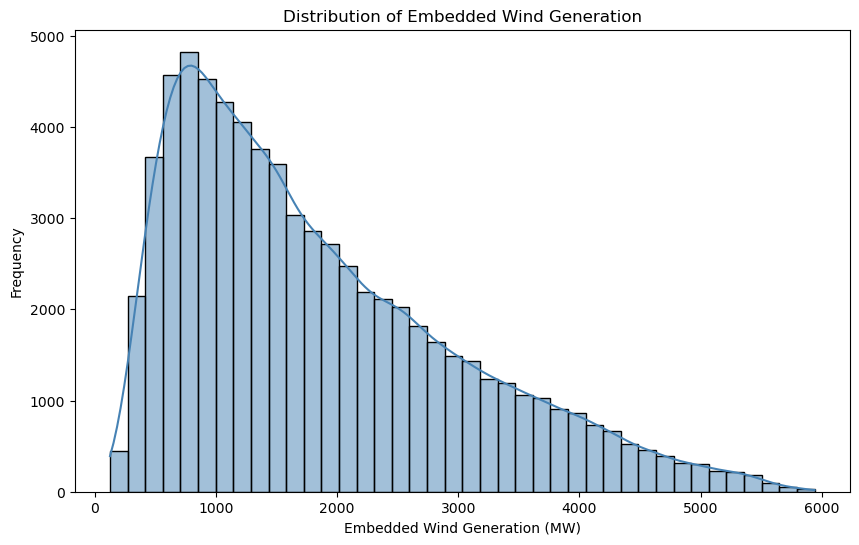

In [27]:
#histogram
plt.figure(figsize=(10,6))

sns.histplot(
    vws_dataset["EMBEDDED_WIND_GENERATION"],
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Embedded Wind Generation")
plt.xlabel("Embedded Wind Generation (MW)")
plt.ylabel("Frequency")

plt.show()

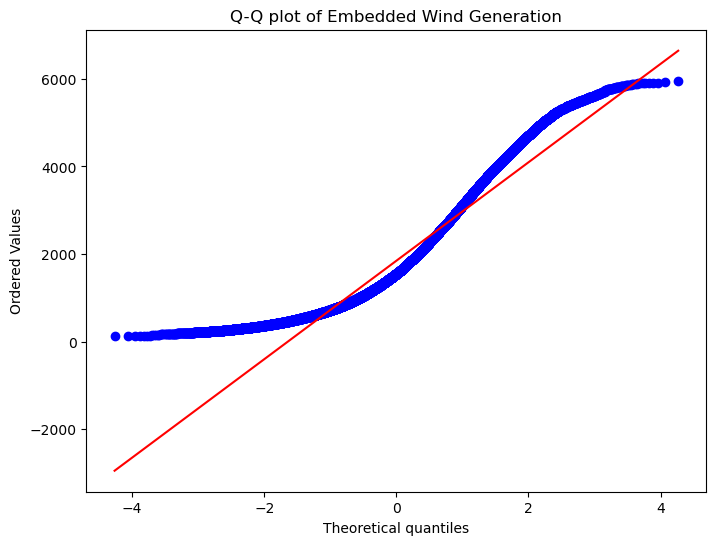

In [28]:
#qq_plot

plt.figure(figsize=(8,6))

stats.probplot(vws_dataset["EMBEDDED_WIND_GENERATION"], dist="norm", plot=plt)

plt.title("Q-Q plot of Embedded Wind Generation")

plt.show()

In [29]:
#skewness and kurtosis

skewness = stats.skew(vws_dataset["EMBEDDED_WIND_GENERATION"])
kurtosis = stats.kurtosis(vws_dataset["EMBEDDED_WIND_GENERATION"])

print(f"Skewness: {skewness: .3f}")
print(f"Kurtosis: {kurtosis: .3f}")

Skewness:  0.911
Kurtosis:  0.170


In [36]:
f_sample = vws_dataset["EMBEDDED_WIND_GENERATION"]

stat, p = shapiro(f_sample)

print("Shapiro Wilk Test")
print(f"Statistics: {stat: .3f}")
print(f"P-value: {p: .4e}")

if p > 0.05:
    print("Fail to reject NH, it is normally distributed")
else:
    print("Reject NH, it is not distributed normally")

Shapiro Wilk Test
Statistics:  0.922
P-value:  5.8255e-98
Reject NH, it is not distributed normally


c:\Users\LOQ\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 70120.
  res = hypotest_fun_out(*samples, **kwds)


In [58]:
#shapiro wilk test has best result for smaller dataset

t_sample = vws_dataset["EMBEDDED_WIND_GENERATION"].sample(5000, random_state=42)

stat, p = shapiro(t_sample)

print("Shapiro Wilk Test")
print(f"Statistics: {stat: .3f}")
print(f"P-value: {p: .4e}")

if p > 0.05:
    print("Fail to reject Null Hypothesis: It is normally distributed")
else:
    print("Reject Null Hypothese: It is not distributed normally")

Shapiro Wilk Test
Statistics:  0.926
P-value:  2.3880e-44
Reject Null Hypothese: It is not distributed normally


In [39]:
stat, p=normaltest(f_sample)

print("D'Angostino Normality Test")
print(f"Statistics: {stat: .4e}")
print(f"P-value: {p: .4e}")

if p > 0.05:
    print("Fail to reject null hypothesis, it is normally distributed")
else:
    print("Reject null hypothesis, it is not distributed normally")

D'Angostino Normality Test
Statistics:  7.2737e+03
P-value:  0.0000e+00
Reject null hypothesis, it is not distributed normally


In [60]:
#anderson-darling test

result = anderson(f_sample, dist="norm")

print("Anderson-Darling Test")
print(f"Statistics: {result.statistic: .4f}")

for sl, cv in zip(result.significance_level, result.critical_values):
    print(f"Significance Level: {sl}& | Critical Value: {cv}")

if result.statistic.all() > result.critical_values.all():
    print("Reject normality assumption")
else:
    print("Appears Normally distributed")

Anderson-Darling Test
Statistics:  1613.6035
Significance Level: 15.0& | Critical Value: 0.576
Significance Level: 10.0& | Critical Value: 0.656
Significance Level: 5.0& | Critical Value: 0.787
Significance Level: 2.5& | Critical Value: 0.918
Significance Level: 1.0& | Critical Value: 1.092
Appears Normally distributed


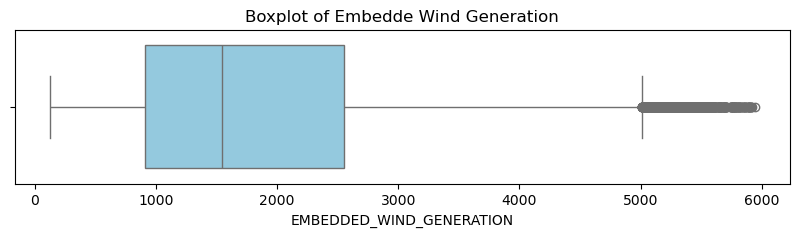

In [80]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=f_sample,
    color="skyblue"
)

plt.title("Boxplot of Embedde Wind Generation")

plt.show()

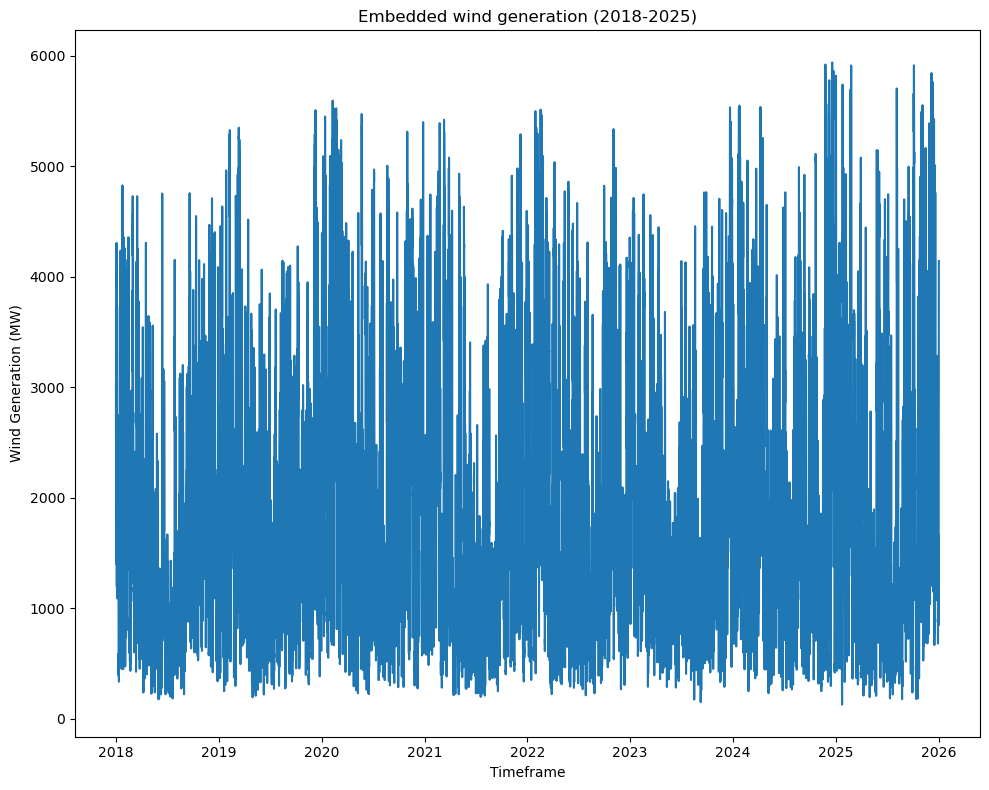

In [43]:
plt.figure(figsize=(10,8))

sns.lineplot(
    vws_dataset,
    x="timestamp",
    y="EMBEDDED_WIND_GENERATION"    
)

plt.title("Embedded wind generation (2018-2025)")
plt.xlabel("Timeframe")
plt.ylabel("Wind Generation (MW)")
plt.tight_layout()

plt.show()

<Axes: xlabel='EMBEDDED_WIND_GENERATION', ylabel='Count'>

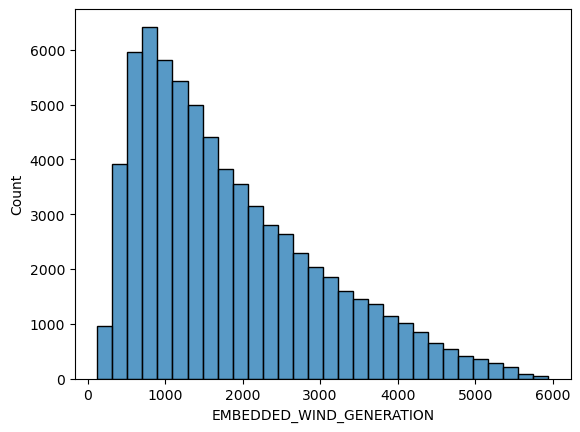

In [100]:
sns.histplot(vws_dataset["EMBEDDED_WIND_GENERATION"], bins=30)

<Axes: xlabel='hour', ylabel='EMBEDDED_WIND_GENERATION'>

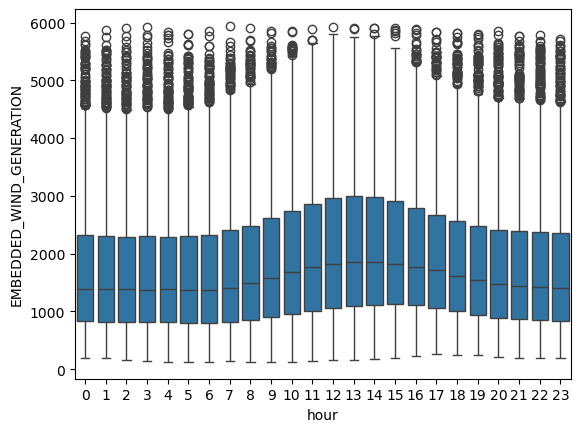

In [102]:
vws_dataset["hour"] = vws_dataset["timestamp"].dt.hour
sns.boxplot(vws_dataset, x = "hour", y= "EMBEDDED_WIND_GENERATION")

<Axes: xlabel='month', ylabel='EMBEDDED_WIND_GENERATION'>

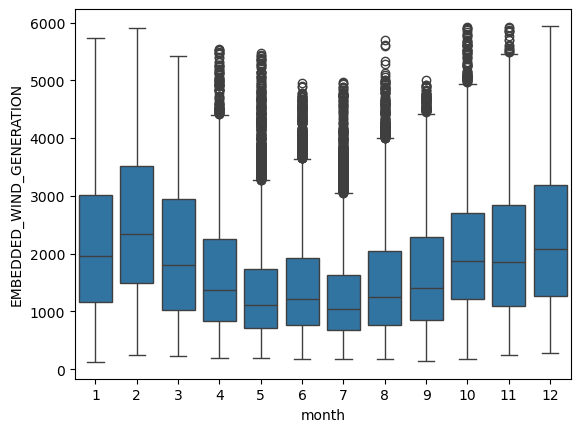

In [106]:
vws_dataset["month"] = vws_dataset["timestamp"].dt.month

sns.boxplot(vws_dataset, x="month", y="EMBEDDED_WIND_GENERATION")

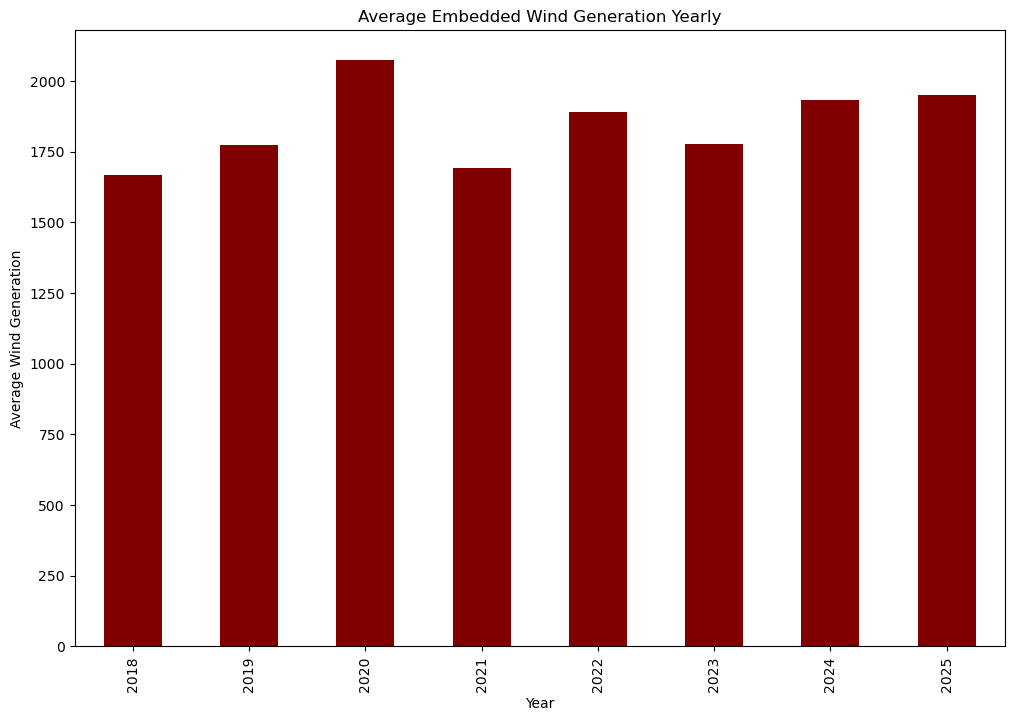

In [126]:
monthly_avg = (
    vws_dataset
    .groupby(vws_dataset["timestamp"].dt.year)["EMBEDDED_WIND_GENERATION"]
    .mean()
)

plt.figure(figsize=(12,8))
monthly_avg.plot(kind="bar", color="maroon")
plt.title("Average Embedded Wind Generation Yearly")
plt.xlabel("Year")
plt.ylabel("Average Wind Generation")
plt.show()

<Axes: ylabel='EMBEDDED_WIND_GENERATION'>

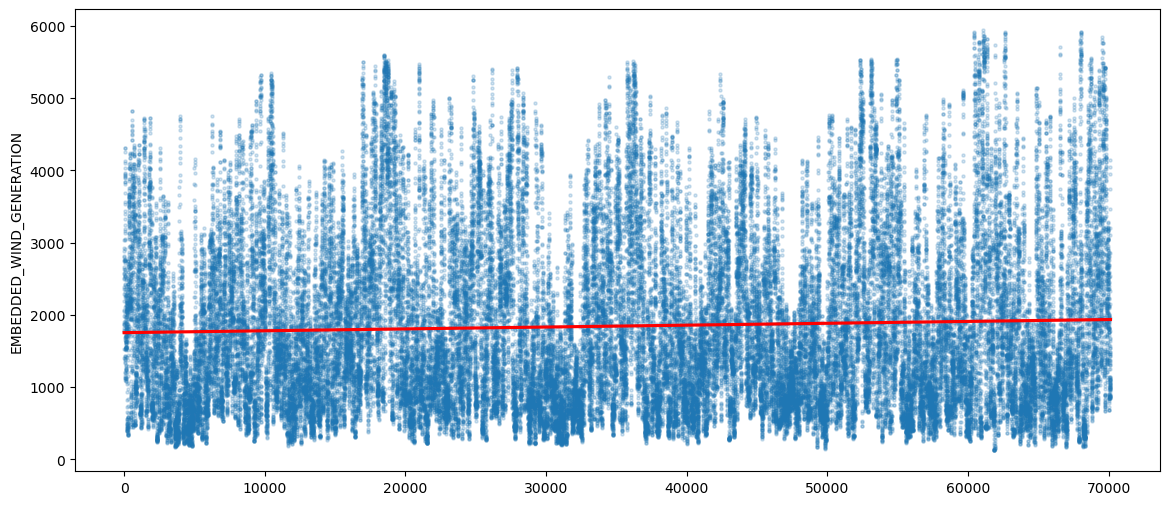

In [144]:
plt.figure(figsize=(14,6))

sns.regplot(
    vws_dataset,
    x=vws_dataset.index,
    y="EMBEDDED_WIND_GENERATION",
    scatter_kws={'s':5, 'alpha':0.2},
    line_kws={'color': 'red'}
)

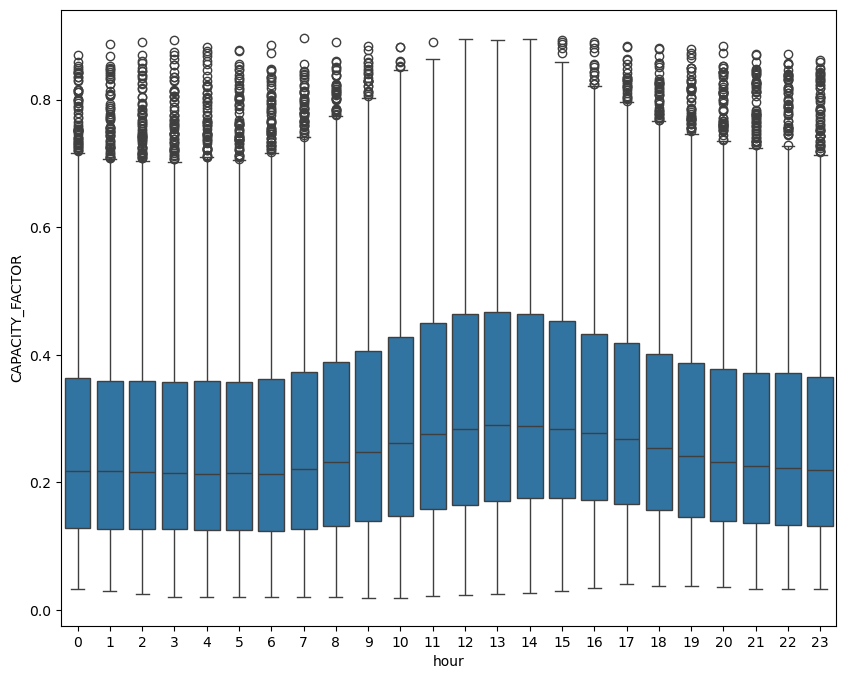

In [25]:
plt.figure(figsize=(10,8))#

sns.boxplot(
    vws_dataset, x="hour", y="CAPACITY_FACTOR"
)

plt.show()

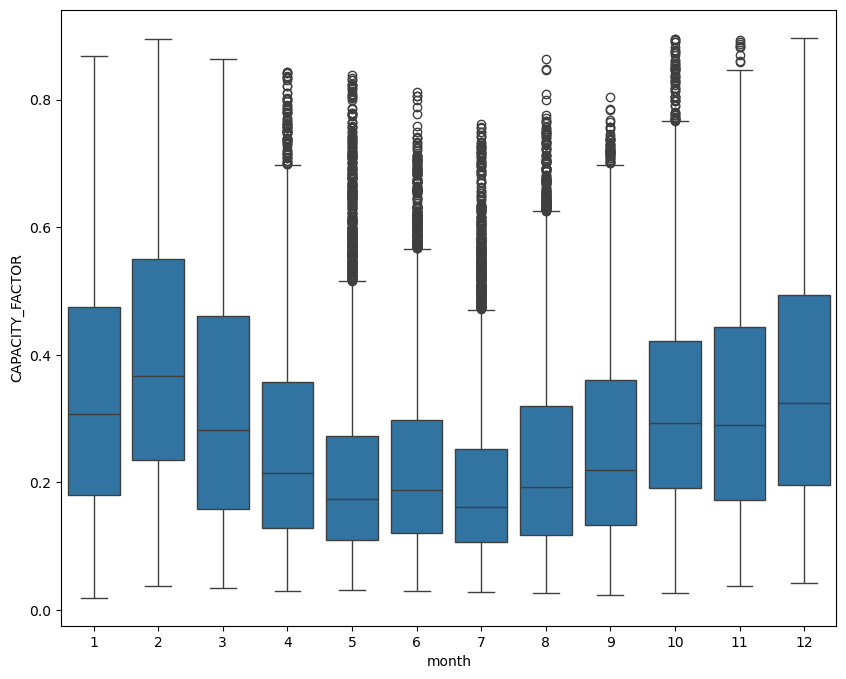

In [23]:
plt.figure(figsize=(10,8))

sns.boxplot(
    vws_dataset, x="month", y="CAPACITY_FACTOR"
)

plt.show()

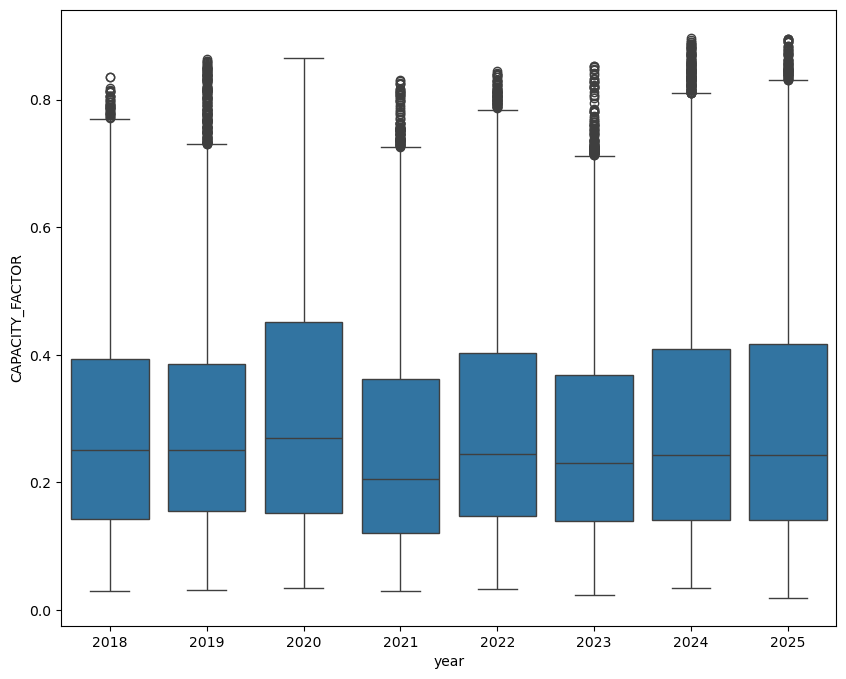

In [24]:
plt.figure(figsize=(10,8))

sns.boxplot(
    vws_dataset, x="year", y="CAPACITY_FACTOR"
)

plt.show()

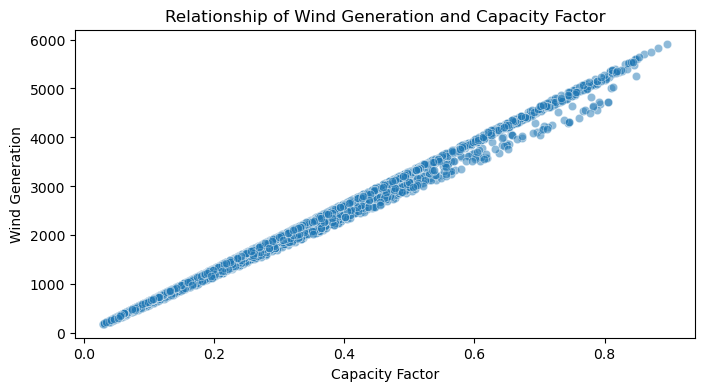

In [50]:
#generation vs capacity factor
plt.figure(figsize=(8,4))

sns.scatterplot(
    data=vws_dataset.sample(5000, random_state=42),
    x="CAPACITY_FACTOR",
    y="EMBEDDED_WIND_GENERATION",
    alpha=0.5
)

plt.title("Relationship of Wind Generation and Capacity Factor")
plt.xlabel("Capacity Factor")
plt.ylabel("Wind Generation")

plt.show()

Weather Variables

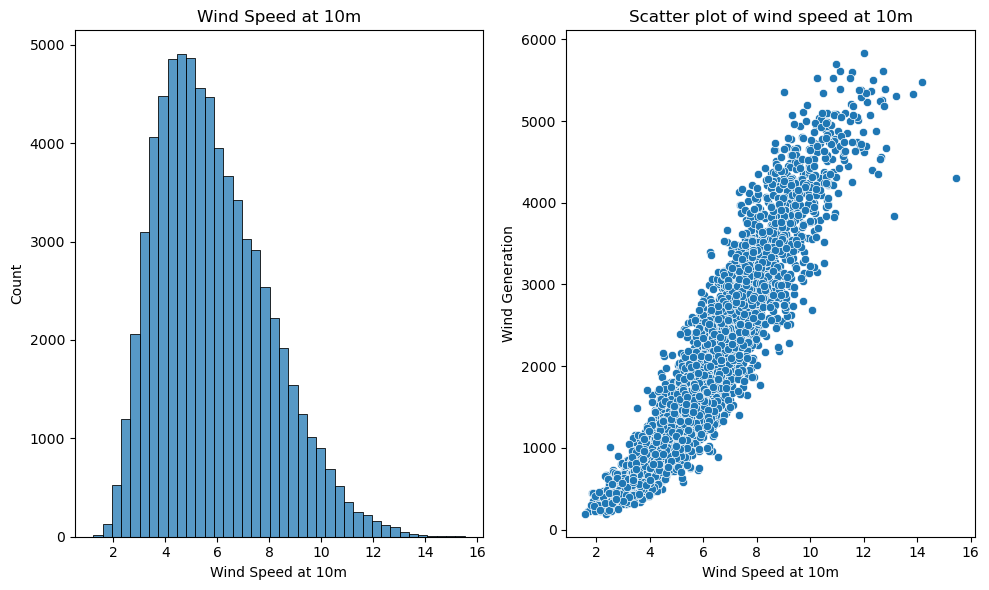

In [59]:
#histogram

plt.figure(figsize=(10,6))


plt.subplot(1,2,1)
sns.histplot(
    vws_dataset["ws10"],
    bins=40
)
plt.xlabel("Wind Speed at 10m")
plt.title("Wind Speed at 10m")

plt.subplot(1,2,2)
sns.scatterplot(
    vws_dataset.sample(4000, random_state=42),
    x="ws10",
    y="EMBEDDED_WIND_GENERATION"
)
plt.xlabel("Wind Speed at 10m")
plt.ylabel("Wind Generation")
plt.title("Scatter plot of wind speed at 10m")

plt.tight_layout()
plt.show()

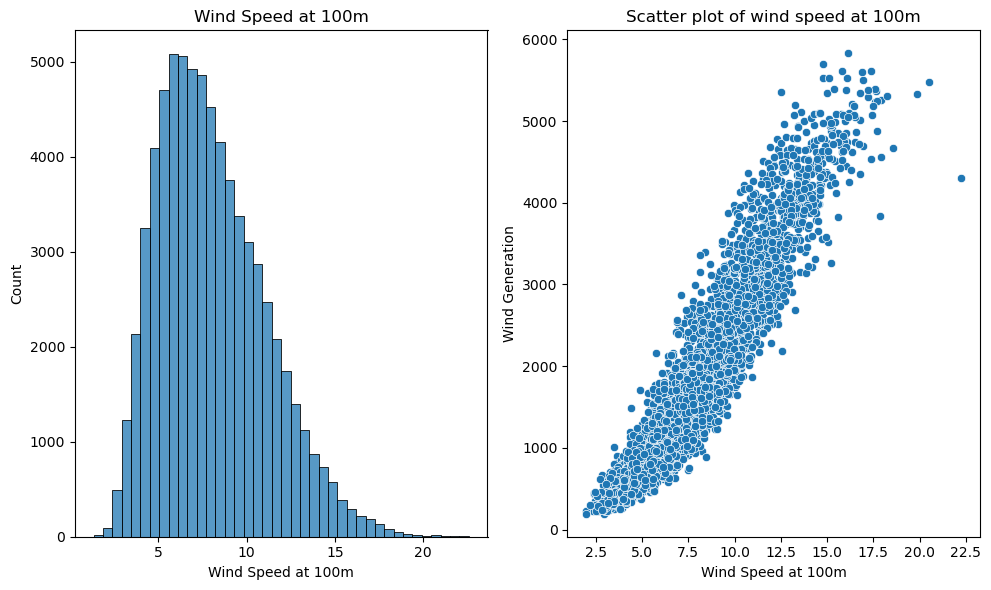

In [60]:
#histogram

plt.figure(figsize=(10,6))


plt.subplot(1,2,1)
sns.histplot(
    vws_dataset["ws100"],
    bins=40
)
plt.xlabel("Wind Speed at 100m")
plt.title("Wind Speed at 100m")

plt.subplot(1,2,2)
sns.scatterplot(
    vws_dataset.sample(4000, random_state=42),
    x="ws100",
    y="EMBEDDED_WIND_GENERATION"
)
plt.xlabel("Wind Speed at 100m")
plt.ylabel("Wind Generation")
plt.title("Scatter plot of wind speed at 100m")

plt.tight_layout()
plt.show()

In [19]:
vws_dataset["year"] = vws_dataset["timestamp"].dt.year

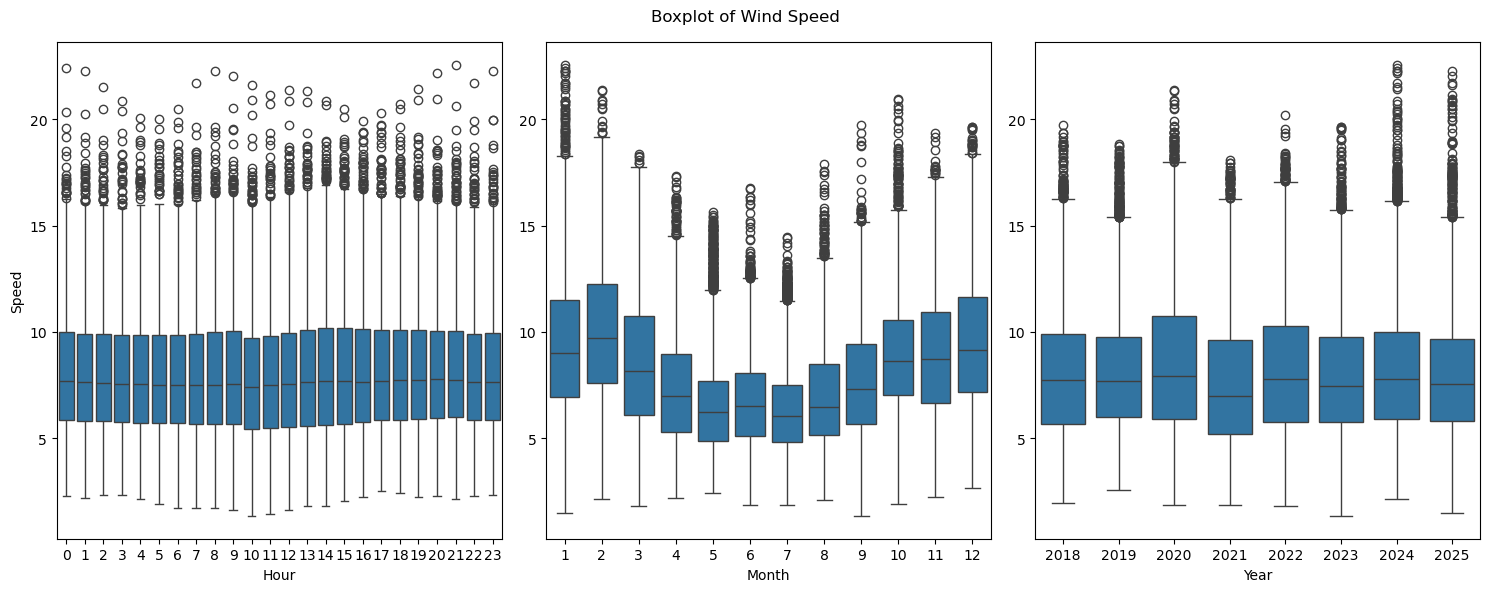

In [27]:
plt.figure(figsize=(15,6))

plt.subplot(1,3,1)
sns.boxplot(
    vws_dataset,
    x="hour",
    y="ws100"
)
plt.xlabel("Hour")
plt.ylabel("Speed")

plt.subplot(1,3,2)
sns.boxplot(
    vws_dataset,
    x="month",
    y="ws100"
)
plt.xlabel("Month")
plt.ylabel(None)

plt.subplot(1,3,3)
sns.boxplot(
    vws_dataset,
    x="year",
    y="ws100"
)
plt.xlabel("Year")
plt.ylabel(None)

plt.suptitle("Boxplot of Wind Speed")
plt.tight_layout()

plt.show()

In [8]:
#!pip install windrose

  Using cached windrose-1.10.0-py3-none-any.whl.metadata (5.3 kB)
Using cached windrose-1.10.0-py3-none-any.whl (20 kB)


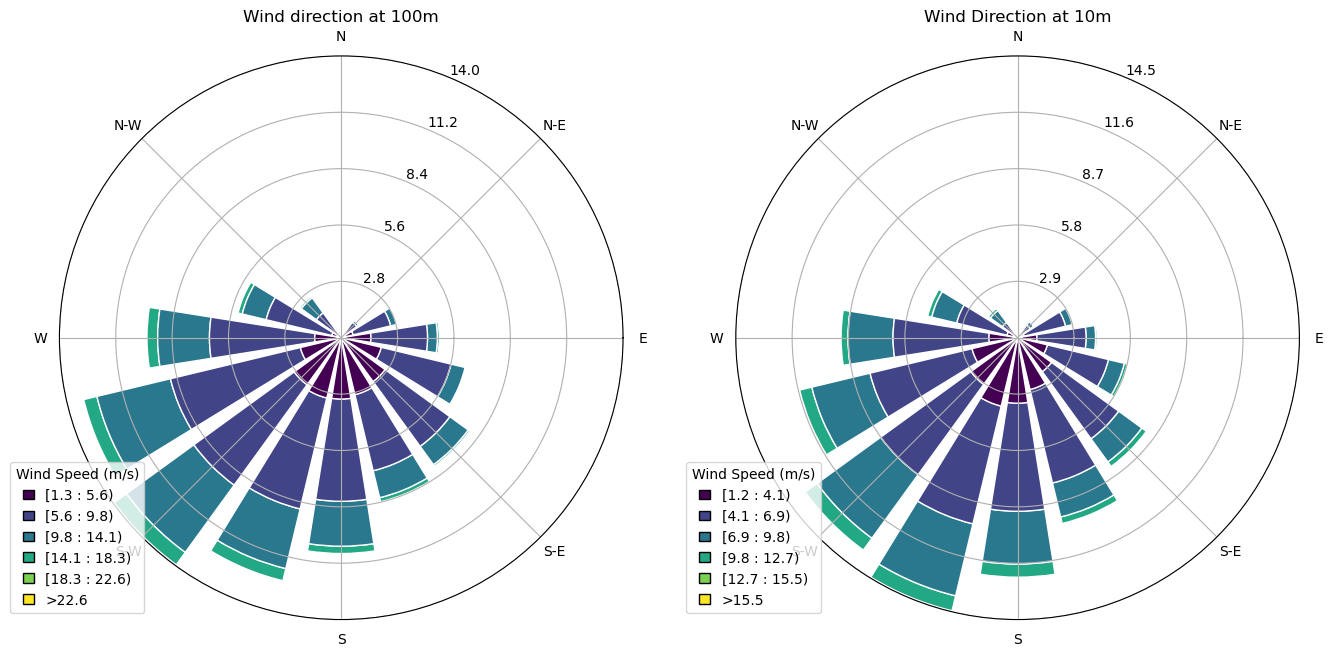

In [42]:
from windrose import WindroseAxes

fig, ax= plt.subplots(
    1,2,
    figsize=(16,8),
    subplot_kw={"projection":"windrose"},
    squeeze=True
)

ax[0].bar(
    vws_dataset["wd100"],
    vws_dataset["ws100"],
    normed=True,
    opening=0.8,
    edgecolor="white"
)

ax[0].set_title("Wind direction at 100m", pad=25)
ax[0].legend(
    title="Wind Speed (m/s)",
    loc= "lower left",
    bbox_to_anchor = (-0.10, 0.0),
    handlelength = 0.8
)

ax[1].bar(
    vws_dataset["wd10"],
    vws_dataset["ws10"],
    normed=True,
    opening=0.8,
    edgecolor="white"
)

ax[1].set_title("Wind Direction at 10m", pad=25)
ax[1].legend(
    title="Wind Speed (m/s)",
    loc= "lower left",
    bbox_to_anchor = (-0.10, 0.0),
    handlelength = 0.8
)


plt.show()

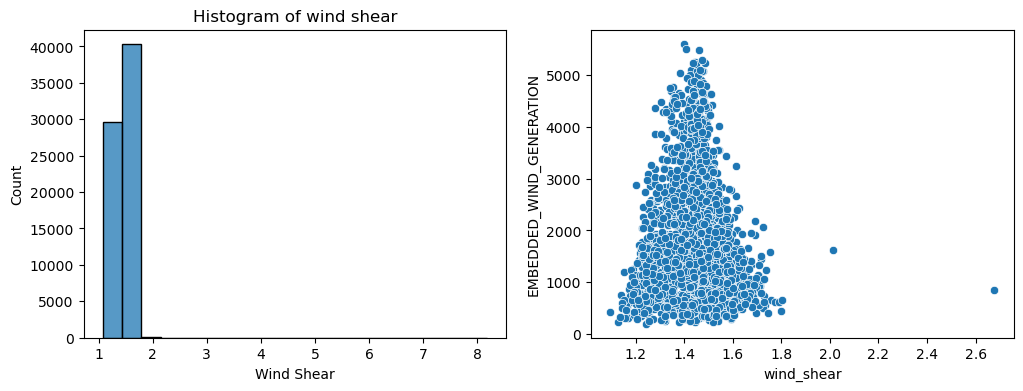

In [53]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(
    vws_dataset["wind_shear"],
    bins=20
)

plt.xlabel("Wind Shear")
plt.ylabel("Count")
plt.title("Histogram of wind shear")

plt.subplot(1,2,2)
sns.scatterplot(
    vws_dataset.sample(2000, random_state=42),
    x="wind_shear",
    y="EMBEDDED_WIND_GENERATION"
)

plt.show()

In [61]:
sort = vws_dataset["wind_shear"].sort_values()

In [65]:
sort.tail(10)

31990    2.265958
58501    2.396887
21091    2.402666
24004    2.659900
47874    2.677499
12954    2.931367
22905    3.077105
63227    4.050456
66157    5.097826
24052    8.180838
Name: wind_shear, dtype: float64

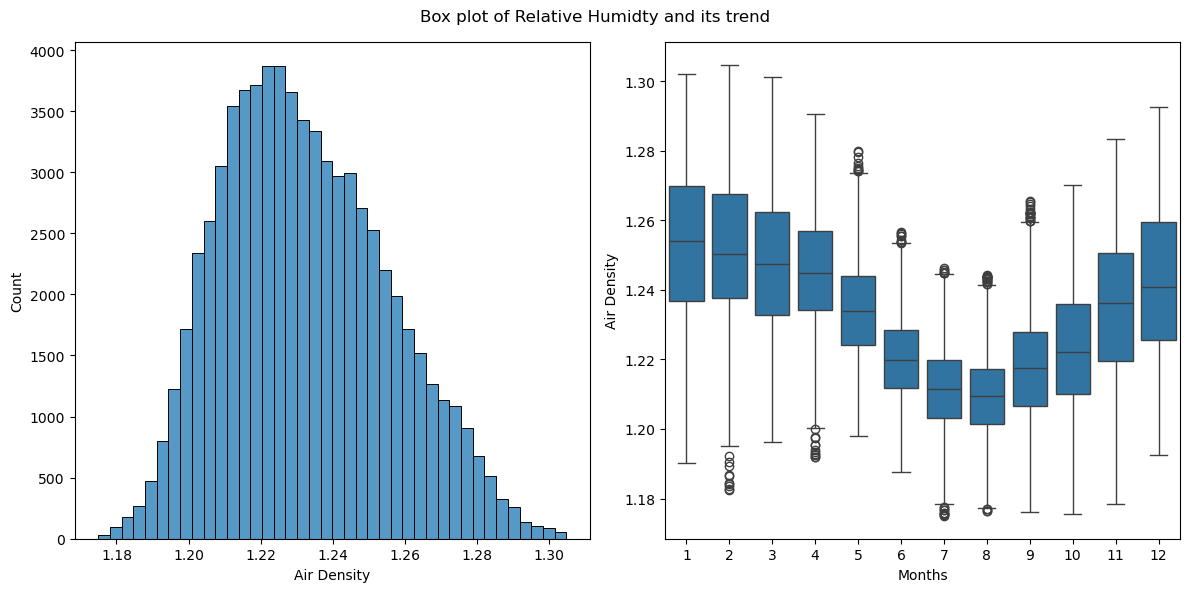

In [89]:
#air_density
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.histplot(
    vws_dataset["air_density"],
    bins=40
)
plt.xlabel("Air Density")

plt.subplot(1,2,2)
sns.boxplot(
    vws_dataset,
    x="month",
    y="air_density"
)
plt.ylabel("Air Density")
plt.xlabel("Months")

plt.suptitle("Box plot of Relative Humidty and its trend")
plt.tight_layout()
plt.show()

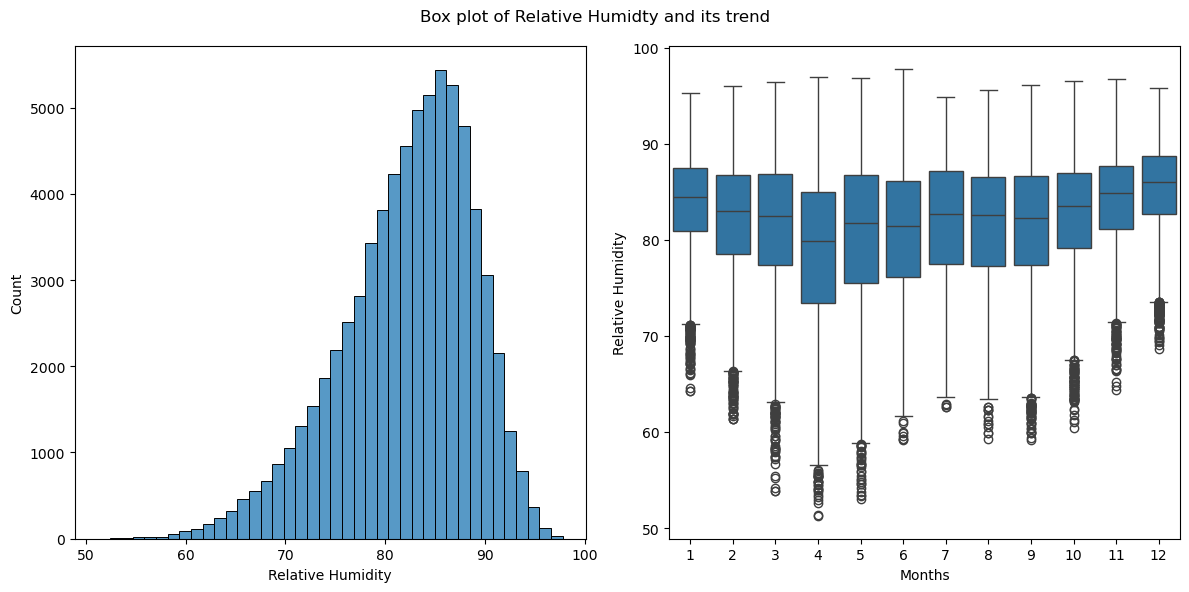

In [86]:
#relative_humidity
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.histplot(
    vws_dataset["relative_humidity"],
    bins=40
)
plt.xlabel("Relative Humidity")

plt.subplot(1,2,2)
sns.boxplot(
    vws_dataset,
    x="month",
    y="relative_humidity"
)
plt.ylabel("Relative Humidity")
plt.xlabel("Months")

plt.suptitle("Box plot of Relative Humidty and its trend")
plt.tight_layout()
plt.show()

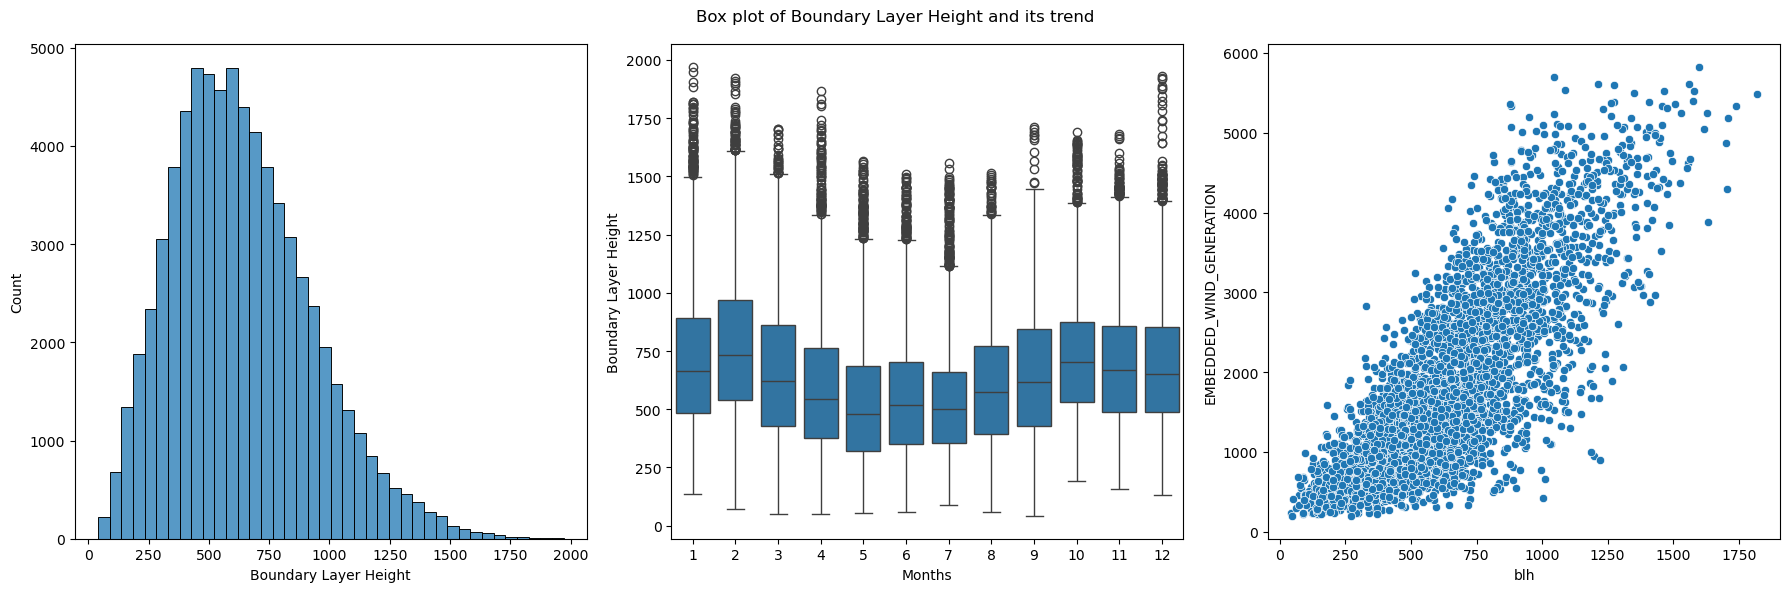

In [91]:
#blh

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
sns.histplot(
    vws_dataset["blh"],
    bins=40
)
plt.xlabel("Boundary Layer Height")

plt.subplot(1,3,2)
sns.boxplot(
    vws_dataset,
    x="month",
    y="blh"
)
plt.ylabel("Boundary Layer Height")
plt.xlabel("Months")

plt.subplot(1,3,3)
sns.scatterplot(
    vws_dataset.sample(4000, random_state=42),
    x="blh",
    y="EMBEDDED_WIND_GENERATION"
)

plt.suptitle("Box plot of Boundary Layer Height and its trend")
plt.tight_layout()
plt.show()

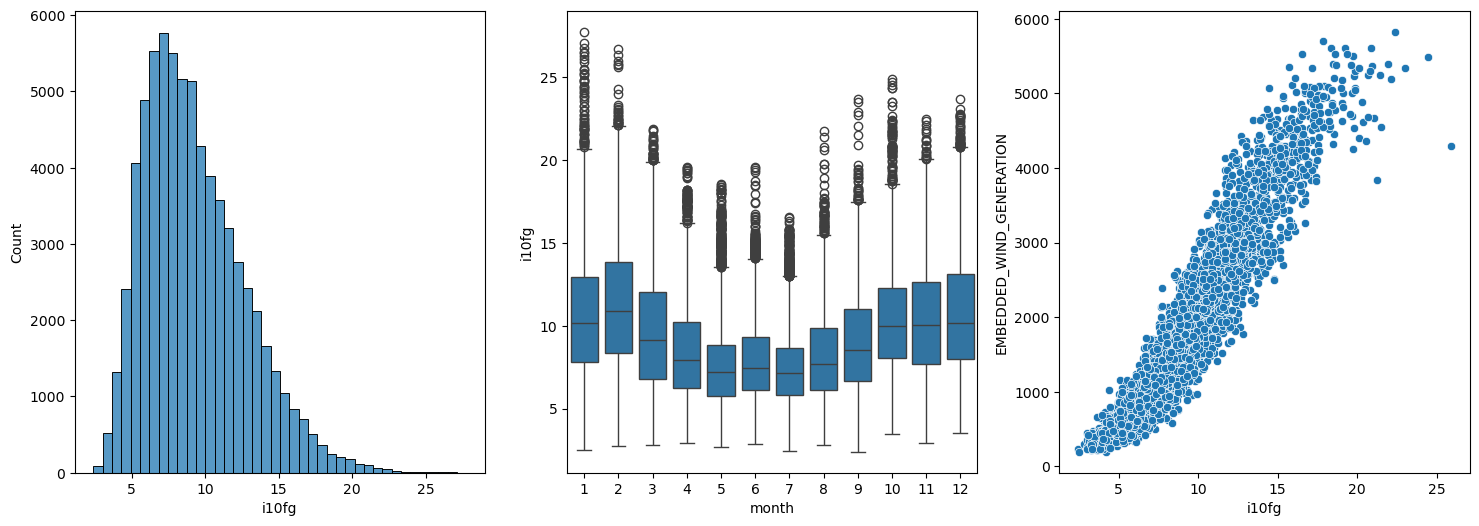

In [96]:
#ins10

#blh

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
sns.histplot(
    vws_dataset["i10fg"],
    bins=40
)

plt.subplot(1,3,2)
sns.boxplot(
    vws_dataset,
    x="month",
    y="i10fg"
)

plt.subplot(1,3,3)
sns.scatterplot(
    vws_dataset.sample(4000, random_state=42),
    x="i10fg",
    y="EMBEDDED_WIND_GENERATION"
)

plt.show()

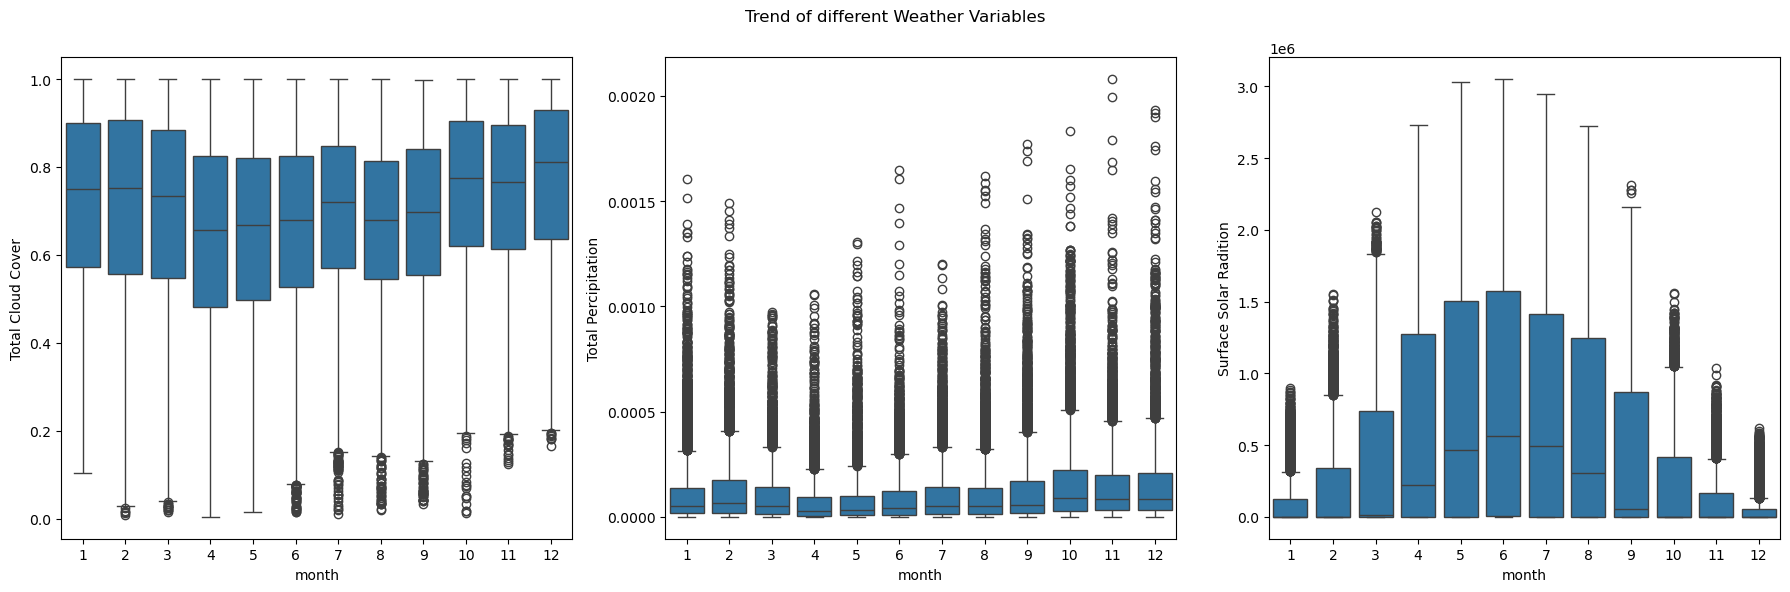

In [75]:
#blh

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
sns.boxplot(
    vws_dataset,
    x="month",
    y="tcc"
)
plt.ylabel("Total Cloud Cover")

plt.subplot(1,3,2)
sns.boxplot(
    vws_dataset,
    x="month",
    y="tp"
)
plt.ylabel("Total Percipitation")

plt.subplot(1,3,3)
sns.boxplot(
    vws_dataset,
    x="month",
    y="ssrd"
)
plt.ylabel("Surface Solar Radition")

plt.suptitle("Trend of different Weather Variables")
plt.tight_layout()
plt.show()

In [4]:
vws_data = vws_dataset

In [ ]:
# removing timeline variables for correlation matrix
#del vws_data["timestamp"]

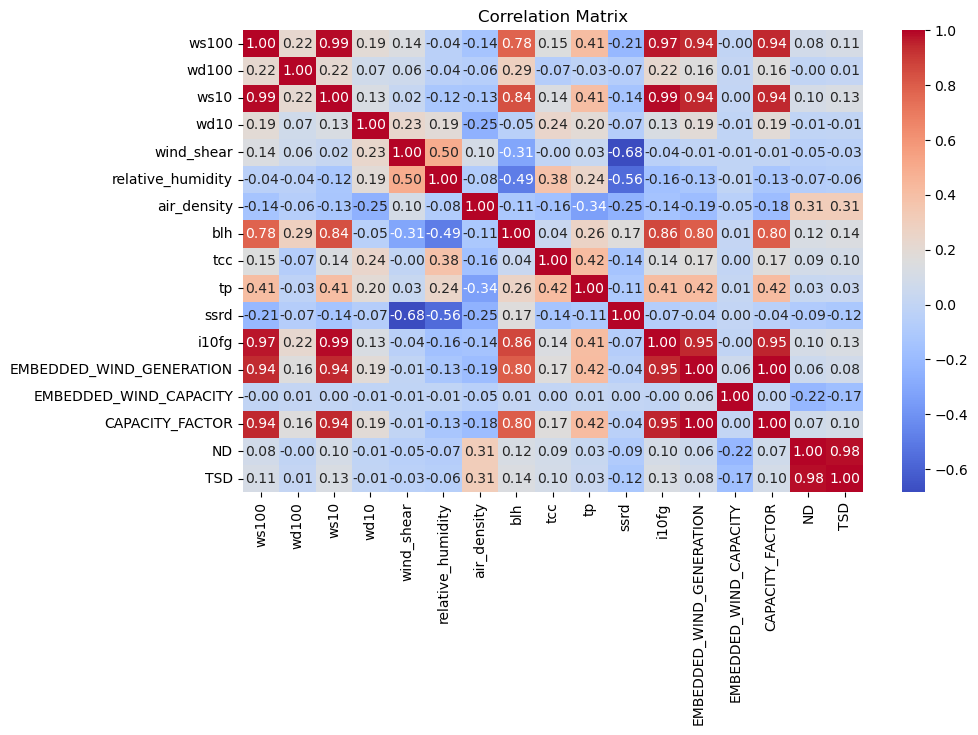

In [7]:
#correlation matrix

corr_matrix = vws_data.corr(numeric_only=True)

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True, #show values
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()


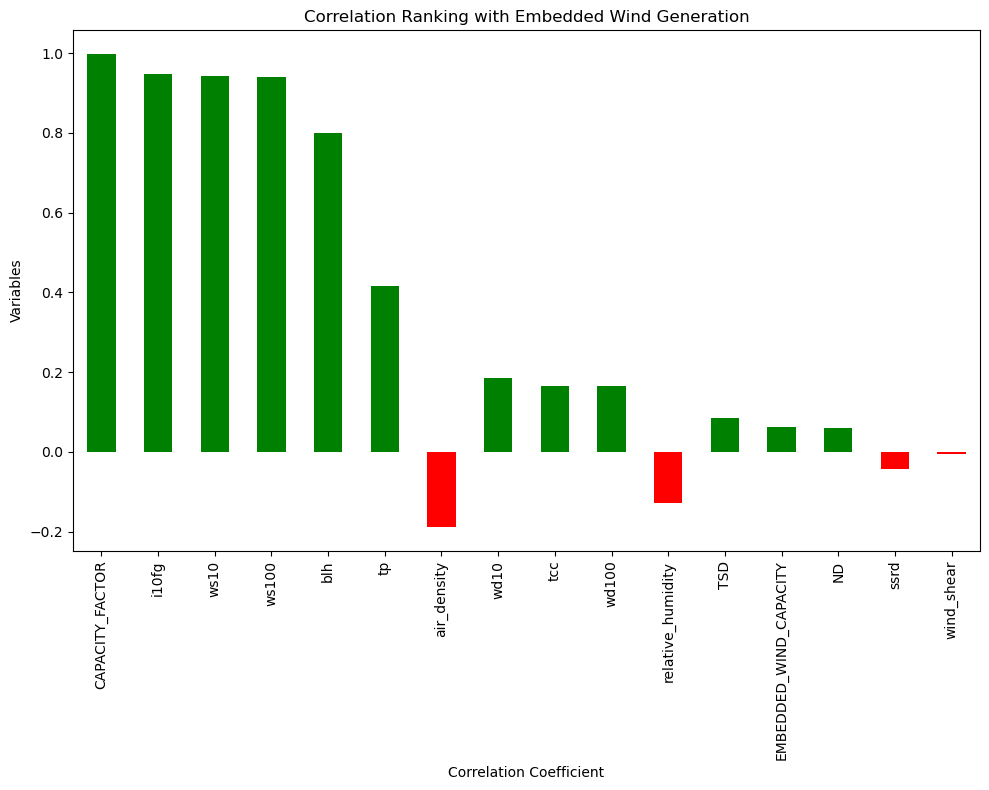

In [13]:
#correlation with target variable

corr_ranking = (
    corr_matrix["EMBEDDED_WIND_GENERATION"]
    .drop("EMBEDDED_WIND_GENERATION")
    .sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(10,8))

corr_ranking.plot(
    kind="bar",
    color=["green" if x>0 else "red" for x in corr_ranking]
)

plt.xlabel("Correlation Coefficient")
plt.ylabel("Variables")
plt.title("Correlation Ranking with Embedded Wind Generation")

plt.tight_layout()
plt.show()

In [15]:
multi_corr = corr_matrix.drop("EMBEDDED_WIND_GENERATION")

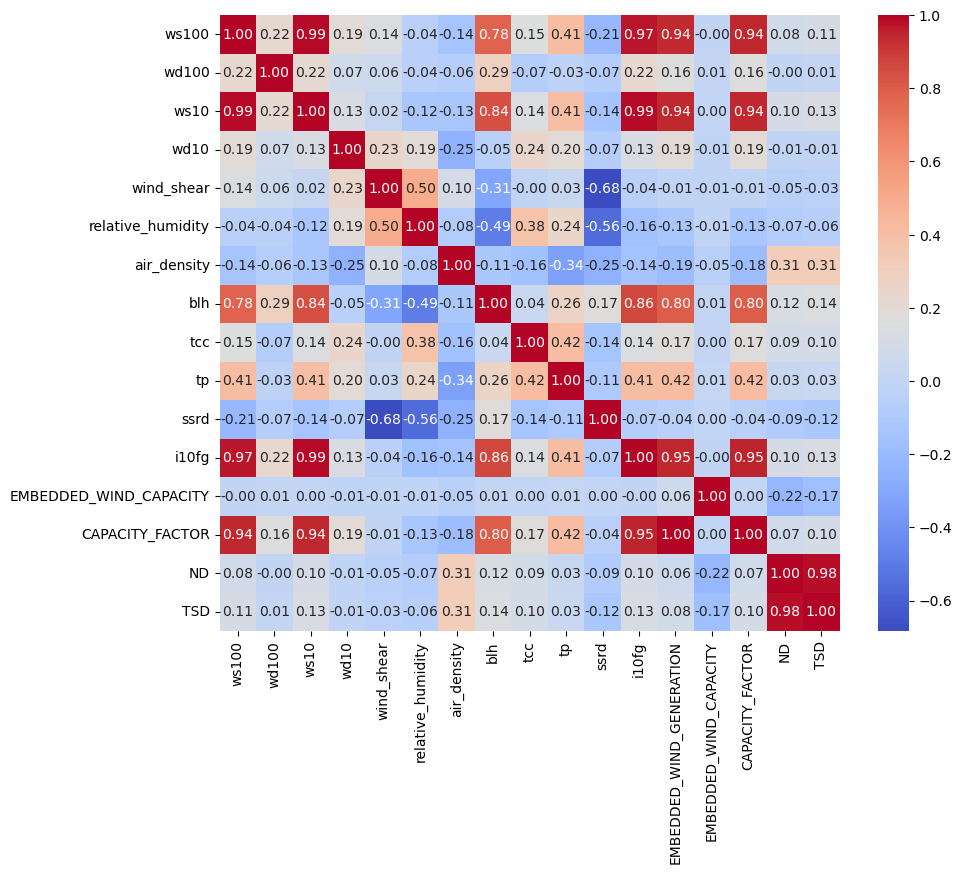

In [17]:
plt.figure(figsize=(10,8))

sns.heatmap(
    multi_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

In [21]:
%reset